# SSVEP / cVEP Command Extraction — Analysis Notebook
**Extraction of Robust Commands from SSVEP Signals for Use in Brain-Computer Interfaces**
Farooq Danesh Amooz — University of Tabriz (supervisor: Prof. Hadi Seyedarabi)

**Data status:** prototype/pipeline-validation batch. Single subject (N=1), one trial per key
(SSVEP single-key, cVEP single-key), or one trial per key under simultaneous multi-key
flicker (SSVEP multi-key, cVEP multi-key). No **hardware synchronization marker** was used for
this batch. All accuracy numbers in this notebook must be reported as **prototype/pipeline
validation results**, not <span style="color:red">final subject-level findings</span>.

**How to reuse this notebook:** set `DATA_DIR` in the next cell to the folder containing your
`.edf` files before re-running.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.cross_decomposition import CCA


DATA_DIR = r"C:\university\6th Term\ssvep-robust-bci\data\raw\SSVEP"


TARGET_FREQS = [8, 9, 10, 12, 13]  # Backward, Right, Stop, Forward, Left
SSVEP_TRUTH = {
    'SF': 12, 'SB': 8, 'SL': 13, 'SR': 9, 'SS': 10,     # single-key
    'SMB': 8, 'SML': 13, 'SMS': 10,                       # multi-key (only 3 of 5 keys experimented)
}
KEY_NAMES = {8: 'Backward', 9: 'Right', 10: 'Stop', 12: 'Forward', 13: 'Left'}

def load_pick_crop(edf_path, channels, l_freq=None, h_freq=None):
    """Shared loader: pick channels, optional filter, standardized 4s analysis window
    (1-5s for 5s recordings, 3-7s for 10s recordings)."""
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw_p = raw.copy().pick(channels)
    if l_freq is not None or h_freq is not None:
        raw_p.filter(l_freq=l_freq, h_freq=h_freq, verbose='ERROR')
    dur = raw.n_times / raw.info['sfreq']
    tmin, tmax = (1.0, 5.0) if dur < 7 else (3.0, 7.0)
    raw_crop = raw_p.copy().crop(tmin=tmin, tmax=min(tmax, dur - 0.01))
    return raw, raw_crop

print("Setup complete.")

Setup complete.


---
# Part 1 — SSVEP Frequency Recognition

Five methods are tested, in increasing order of sophistication. Each subsection includes:
method explanation, code, results on the real recorded data, and a visualization.

## 1.1 Baseline: Single-channel FFT, naive argmax

**Method:** take one occipital channel (O1), compute its FFT over the standardized analysis
window, and predict the target frequency as whichever frequency bin has the single highest
magnitude — searched across the *entire* spectrum, no filtering applied first.

**Why this is included:** as a deliberately naive baseline, to demonstrate empirically why
more advanced methods (CCA, FBCCA, TRCA) exist in the literature.

In [34]:
def classify_fft_argmax(edf_path):
    raw, raw_crop = load_pick_crop(edf_path, ['O1'])
    data = raw_crop.get_data()[0]
    freqs = np.fft.rfftfreq(data.shape[0], d=1/raw.info['sfreq'])
    mag = np.abs(np.fft.rfft(data))
    pred_idx = np.argmax(mag)
    return freqs[pred_idx], freqs, mag

results_fft = {}
print(f"{'File':6s} {'True':6s} {'Pred':8s} {'Result':8s}")
for key, true_f in SSVEP_TRUTH.items():
    pred, freqs, mag = classify_fft_argmax(f'{DATA_DIR}/{key}.edf')
    results_fft[key] = pred
    ok = abs(pred - true_f) < 0.3
    print(f"{key:6s} {true_f:4d}Hz {pred:6.2f}Hz {'CORRECT' if ok else 'WRONG':8s}")

acc_fft = sum(abs(results_fft[k]-v) < 0.3 for k,v in SSVEP_TRUTH.items()) / len(SSVEP_TRUTH)
print(f"\nAccuracy: {acc_fft*100:.0f}% ({sum(abs(results_fft[k]-v)<0.3 for k,v in SSVEP_TRUTH.items())}/{len(SSVEP_TRUTH)})")

File   True   Pred     Result  
SF       12Hz  12.01Hz CORRECT 
SB        8Hz   2.50Hz WRONG   
SL       13Hz   1.25Hz WRONG   
SR        9Hz   9.01Hz CORRECT 
SS       10Hz   1.00Hz WRONG   
SMB       8Hz   1.75Hz WRONG   
SML      13Hz   1.25Hz WRONG   
SMS      10Hz   8.99Hz WRONG   

Accuracy: 25% (2/8)


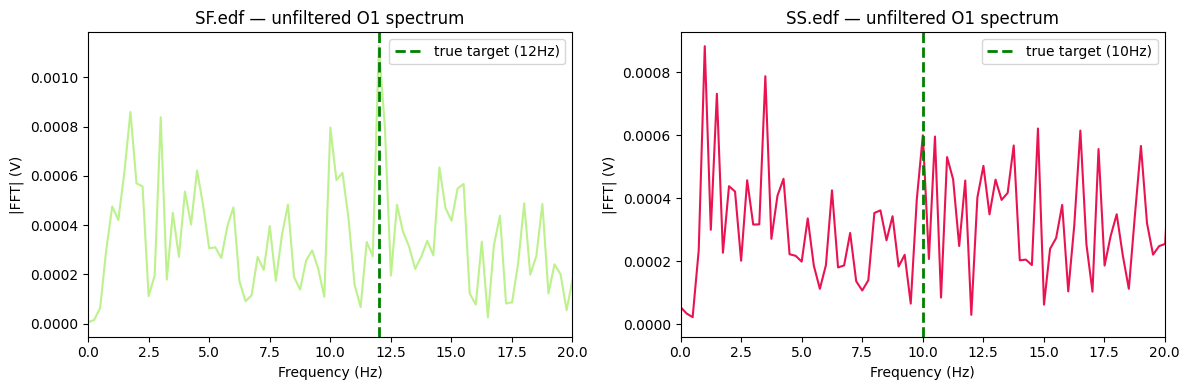

In [35]:
# Visualization: spectrum for a correct case (SF, 12Hz) vs a failing case (SS, 10Hz)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, fkey, true_f in zip(axes, ['SF', 'SS'], [12, 10]):
    raw, raw_crop = load_pick_crop(f'{DATA_DIR}/{fkey}.edf', ['O1'])
    data = raw_crop.get_data()[0]
    freqs = np.fft.rfftfreq(data.shape[0], d=1/raw.info['sfreq'])
    mag = np.abs(np.fft.rfft(data))
    ax.plot(freqs, mag,color= np.random.rand(3,))
    ax.axvline(true_f, color='green', linestyle='--',linewidth=2, label=f'true target ({true_f}Hz)')
    ax.set_xlim(0, 20)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT| (V)')
    ax.set_title(f'{fkey}.edf — unfiltered O1 spectrum')
    ax.legend()
plt.tight_layout()
plt.show()

**Result:** naive single-channel argmax is unreliable — low-frequency baseline drift
(~1-2.5 Hz) frequently wins over the true target peak. This directly motivates spatial
filtering (CCA/TRCA) and harmonic exploitation (FBCCA), as discussed in the reviewed
literature (Zhang et al. 2007 [CCA paper]; Chen et al. 2015 [FBCCA paper]).

## 1.2 Channel-Averaged + Harmonic-Summed FFT

**Method:** average O1 and O2 (simple spatial combination), apply a 5-40 Hz bandpass filter,
then for each candidate frequency sum the FFT magnitude at the fundamental + 2 harmonics.
Predict the candidate with the highest summed score.

In [36]:
def classify_harmonic_sum(edf_path, n_harmonics=3):
    raw, raw_crop = load_pick_crop(edf_path, ['O1', 'O2'], l_freq=5.0, h_freq=40.0)
    data = raw_crop.get_data()
    combined = 0.5*data[0] + 0.5*data[1]
    freqs = np.fft.rfftfreq(combined.shape[0], d=1/raw.info['sfreq'])
    mag = np.abs(np.fft.rfft(combined))
    scores = {}
    for f in TARGET_FREQS:
        total = sum(mag[np.argmin(np.abs(freqs - f*n))] for n in range(1, n_harmonics+1) if f*n < freqs[-1])
        scores[f] = total
    return max(scores, key=scores.get), scores

results_hsum = {}
print(f"{'File':6s} {'True':6s} {'Pred':6s} {'Result':8s}")
for key, true_f in SSVEP_TRUTH.items():
    pred, scores = classify_harmonic_sum(f'{DATA_DIR}/{key}.edf')
    results_hsum[key] = pred
    ok = pred == true_f
    print(f"{key:6s} {true_f:4d}Hz {pred:4d}Hz {'CORRECT' if ok else 'WRONG':8s}")

acc_hsum = sum(results_hsum[k]==v for k,v in SSVEP_TRUTH.items()) / len(SSVEP_TRUTH)
print(f"\nAccuracy: {acc_hsum*100:.0f}% ({sum(results_hsum[k]==v for k,v in SSVEP_TRUTH.items())}/{len(SSVEP_TRUTH)})")

File   True   Pred   Result  
SF       12Hz   12Hz CORRECT 
SB        8Hz    8Hz CORRECT 
SL       13Hz   13Hz CORRECT 
SR        9Hz    9Hz CORRECT 
SS       10Hz    9Hz WRONG   
SMB       8Hz    8Hz CORRECT 
SML      13Hz   12Hz WRONG   
SMS      10Hz   10Hz CORRECT 

Accuracy: 75% (6/8)


9


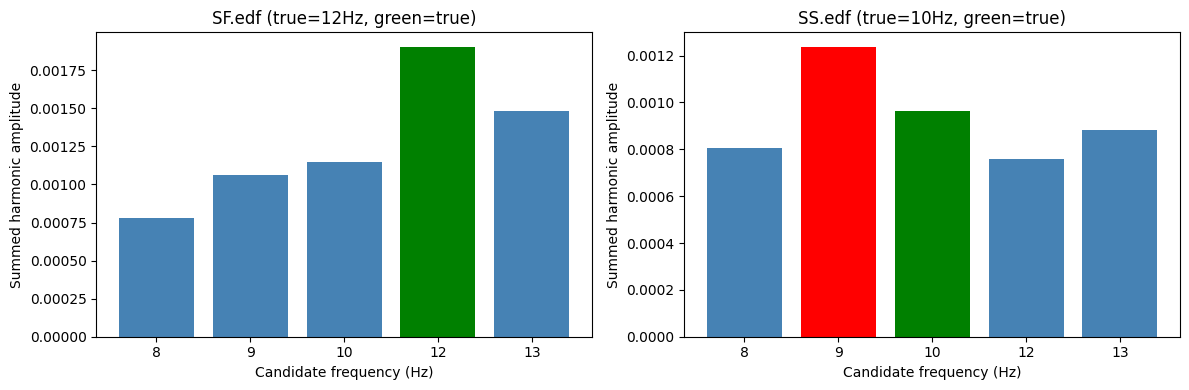

In [37]:
# Visualization: per-candidate summed scores for one correct and one incorrect file
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, fkey, true_f in zip(axes, ['SF', 'SS'], [12, 10]):
    max_pred_score, scores = classify_harmonic_sum(f'{DATA_DIR}/{fkey}.edf')
    colors = []
    for f in TARGET_FREQS:
        if f==true_f:
            colors.append('green')
        else:
            colors.append('steelblue')
        if max_pred_score == f and max_pred_score != true_f:
            colors[-1] = 'red'

    ax.bar([str(f) for f in TARGET_FREQS], [scores[f] for f in TARGET_FREQS], color=colors)
    ax.set_xlabel('Candidate frequency (Hz)')
    ax.set_ylabel('Summed harmonic amplitude')
    ax.set_title(f'{fkey}.edf (true={true_f}Hz, green=true)')
print(max_pred_score)
plt.tight_layout()
plt.show()

**Result:** combining channels and summing harmonics improves accuracy substantially
over the naive baseline, but still misses close-neighbor frequencies (e.g., 9 vs 10 Hz) in
some trials.

## 1.3 Canonical Correlation Analysis (CCA)

**Method:** for each candidate frequency, build a reference signal set (sine + cosine at the
fundamental and 2 harmonics), then use CCA to find the linear combination of EEG channels
(O1, O2, Pz, P3, P4) and the linear combination of the reference set that correlate most
strongly. The candidate with the highest correlation (rho) wins. This is a training-free
method (Lin & Zhang, 2007).

In [38]:
CCA_CHANNELS = ['O1', 'O2', 'Pz', 'P3', 'P4']

def make_reference(freq, n_samples, fs, n_harmonics=3):
    t = np.arange(n_samples) / fs
    ref = []
    for h in range(1, n_harmonics + 1):
        ref.append(np.sin(2*np.pi*h*freq*t))
        ref.append(np.cos(2*np.pi*h*freq*t))
    return np.array(ref).T

def classify_cca(edf_path, n_harmonics=3):
    raw, raw_crop = load_pick_crop(edf_path, CCA_CHANNELS, l_freq=5.0, h_freq=40.0)
    X = raw_crop.get_data().T
    fs = raw.info['sfreq']
    n_samples = X.shape[0]
    scores = {}
    for f in TARGET_FREQS:
        Y = make_reference(f, n_samples, fs, n_harmonics)
        cca = CCA(n_components=1)
        cca.fit(X, Y)
        X_c, Y_c = cca.transform(X, Y)
        scores[f] = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
    return max(scores, key=scores.get), scores

results_cca = {}
print(f"{'File':6s} {'True':6s} {'Pred':6s} {'Result':8s}")
for key, true_f in SSVEP_TRUTH.items():
    pred, scores = classify_cca(f'{DATA_DIR}/{key}.edf')
    results_cca[key] = pred
    ok = pred == true_f
    print(f"{key:6s} {true_f:4d}Hz {pred:4d}Hz {'CORRECT' if ok else 'WRONG':8s}")

acc_cca = sum(results_cca[k]==v for k,v in SSVEP_TRUTH.items()) / len(SSVEP_TRUTH)
print(f"\nAccuracy: {acc_cca*100:.0f}% ({sum(results_cca[k]==v for k,v in SSVEP_TRUTH.items())}/{len(SSVEP_TRUTH)})")

File   True   Pred   Result  
SF       12Hz   12Hz CORRECT 
SB        8Hz    8Hz CORRECT 
SL       13Hz   13Hz CORRECT 
SR        9Hz    9Hz CORRECT 
SS       10Hz   10Hz CORRECT 
SMB       8Hz    8Hz CORRECT 
SML      13Hz   13Hz CORRECT 
SMS      10Hz   10Hz CORRECT 

Accuracy: 100% (8/8)


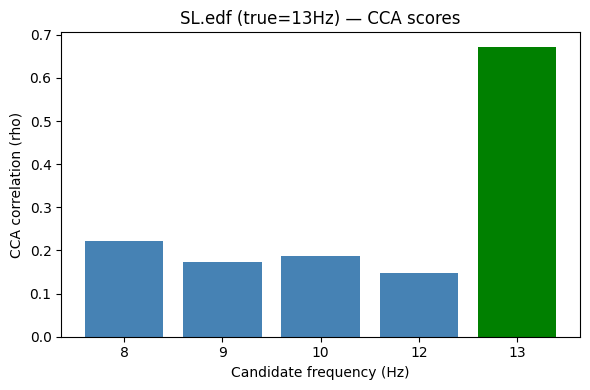

In [39]:
# Visualization: CCA correlation (rho) per candidate frequency, one file
fig, ax = plt.subplots(figsize=(6, 4))
_, scores = classify_cca(f'{DATA_DIR}/SL.edf')
colors = ['green' if f==13 else 'steelblue' for f in TARGET_FREQS]
ax.bar([str(f) for f in TARGET_FREQS], [scores[f] for f in TARGET_FREQS], color=colors)
ax.set_xlabel('Candidate frequency (Hz)')
ax.set_ylabel('CCA correlation (rho)')
ax.set_title('SL.edf (true=13Hz) — CCA scores')
plt.tight_layout()
plt.show()

**Result:** CCA reaches 8/8 on this prototype batch, correcting both cases the harmonic-sum method missed.

## 1.4 Filter Bank CCA (FBCCA)

**Method:** split the signal into 3 overlapping sub-bands (each starting near a harmonic,
all extending to 40 Hz — the "M3" design from [Chen et al., Journal of Neural Engineering](https://pubmed.ncbi.nlm.nih.gov/26035476/)),
run CCA separately per sub-band, and combine sub-band correlations with weights
`w_n = n^-1.25 + 0.25` (published formula — **verify constants against the source PDF before
citing**), summing `w_n * rho_n^2` per candidate frequency.

In [40]:
SUB_BANDS = [(6, 40), (14, 40), (22, 40)]
FB_WEIGHTS = [n**-1.25 + 0.25 for n in range(1, len(SUB_BANDS) + 1)]

def cca_rho(X, Y):
    cca = CCA(n_components=1)
    cca.fit(X, Y)
    X_c, Y_c = cca.transform(X, Y)
    return np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

def classify_fbcca(edf_path, n_harmonics=3):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw_p = raw.copy().pick(CCA_CHANNELS)
    dur = raw.n_times / raw.info['sfreq']
    tmin, tmax = (1.0, 5.0) if dur < 7 else (3.0, 7.0)
    raw_crop = raw_p.copy().crop(tmin=tmin, tmax=min(tmax, dur - 0.01))
    fs = raw.info['sfreq']
    n_samples = raw_crop.n_times

    X_bands = []
    for l_freq, h_freq in SUB_BANDS:
        raw_sub = raw_crop.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose='ERROR')
        X_bands.append(raw_sub.get_data().T)

    scores = {}
    for f in TARGET_FREQS:
        Y = make_reference(f, n_samples, fs, n_harmonics)
        total = sum(w * cca_rho(X_sub, Y)**2 for X_sub, w in zip(X_bands, FB_WEIGHTS))
        scores[f] = total
    return max(scores, key=scores.get), scores

results_fbcca = {}
print(f"{'File':6s} {'True':6s} {'Pred':6s} {'Result':8s}")
for key, true_f in SSVEP_TRUTH.items():
    pred, scores = classify_fbcca(f'{DATA_DIR}/{key}.edf')
    results_fbcca[key] = pred
    ok = pred == true_f
    print(f"{key:6s} {true_f:4d}Hz {pred:4d}Hz {'CORRECT' if ok else 'WRONG':8s}")

acc_fbcca = sum(results_fbcca[k]==v for k,v in SSVEP_TRUTH.items()) / len(SSVEP_TRUTH)
print(f"\nAccuracy: {acc_fbcca*100:.0f}% ({sum(results_fbcca[k]==v for k,v in SSVEP_TRUTH.items())}/{len(SSVEP_TRUTH)})")

File   True   Pred   Result  
SF       12Hz   12Hz CORRECT 
SB        8Hz    8Hz CORRECT 
SL       13Hz   13Hz CORRECT 
SR        9Hz    9Hz CORRECT 
SS       10Hz   10Hz CORRECT 
SMB       8Hz    8Hz CORRECT 
SML      13Hz   13Hz CORRECT 
SMS      10Hz   10Hz CORRECT 

Accuracy: 100% (8/8)


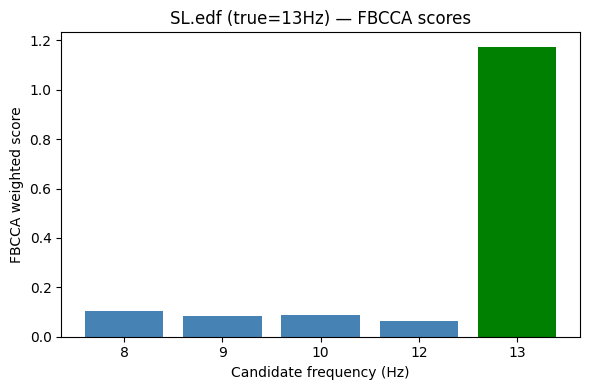

In [41]:
# Visualization: FBCCA vs CCA score margins on the same file (SL.edf)
fig, ax = plt.subplots(figsize=(6, 4))
_, scores = classify_fbcca(f'{DATA_DIR}/SL.edf')
colors = ['green' if f==13 else 'steelblue' for f in TARGET_FREQS]
ax.bar([str(f) for f in TARGET_FREQS], [scores[f] for f in TARGET_FREQS], color=colors)
ax.set_xlabel('Candidate frequency (Hz)')
ax.set_ylabel('FBCCA weighted score')
ax.set_title('SL.edf (true=13Hz) — FBCCA scores')
plt.tight_layout()
plt.show()

**Result:** FBCCA also reaches 8/8. Both CCA and FBCCA are at ceiling on this small
N=1 batch, so raw accuracy cannot distinguish them here — but FBCCA's winning margins
(winning score vs. runner-up) are generally larger, suggesting more confident separation.
This should be reported as a margin/confidence observation, not an accuracy claim, given
both already scored 100%.

## 1.5 TRCA / TDCA — Blocked by Data Requirements (Not Run on Real Data)

**Why these are not applied to the real dataset:** TRCA and TDCA are training-based methods
([Zerafa et al. 2018 taxonomy — subject-specific category](https://doi.org/10.1088/1741-2552/aaca6e)). Their spatial filter is defined by
maximizing consistency **across repeated trials of the same class**. This dataset's SSVEP
single-key files contain exactly **1 trial per key (N=1)** — there is no inter-trial
covariance to compute. Running TRCA/TDCA "code" on N=1 data would not fail with an error; it
would silently produce a degenerate, overfit spatial filter and misleadingly-confident
numbers. That would misrepresent the method, so it is not done here.

**What follows instead:** a working TRCA implementation, demonstrated on synthetic
multi-trial data only (clearly not from the subject), to document the method correctly for
the report without fabricating subject-level results. TDCA is described conceptually only
(a full working implementation was out of scope for this batch given the deadline and the
same N=1 blocker).

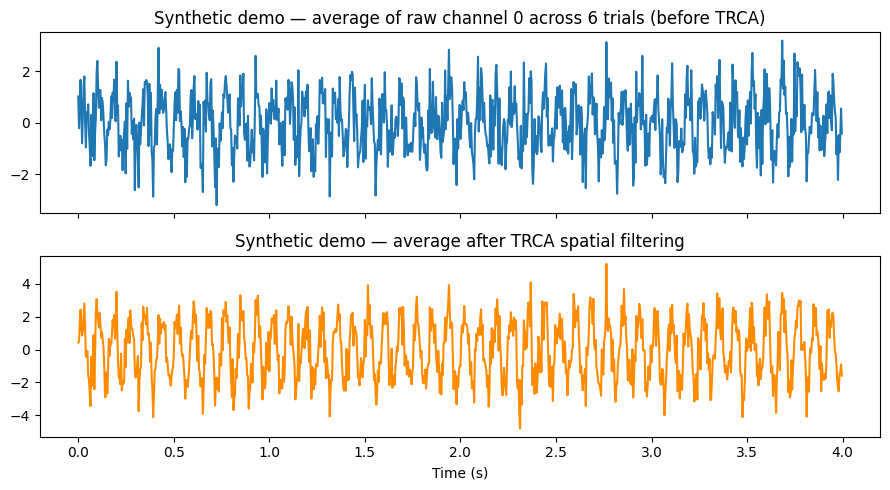

TRCA spatial filter (synthetic demo only): [0.524 0.465 0.542 0.464]


In [42]:
def trca_spatial_filter(trials):
    """trials: list of arrays, each shape (n_channels, n_samples), same class.
    Returns the leading TRCA spatial filter (Nakanishi et al., 2018; Cao et al.)"""
    n_trials = len(trials)
    n_channels = trials[0].shape[0]
    X_sum = sum(trials)
    S = X_sum @ X_sum.T - sum(tr @ tr.T for tr in trials)   # inter-trial covariance
    Q = sum(tr @ tr.T for tr in trials)                      # within-trial covariance
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Q) @ S)
    w = np.real(eigvecs[:, np.argmax(np.real(eigvals))])
    return w

# --- SYNTHETIC DEMONSTRATION ONLY (not subject data) ---
np.random.seed(0)
fs_demo, n_samples_demo, n_channels_demo, n_trials_demo = 250, 1000, 4, 6
t_demo = np.arange(n_samples_demo) / fs_demo
true_signal = np.sin(2*np.pi*12*t_demo)  # synthetic 12Hz "SSVEP-like" component
synthetic_trials = []
for _ in range(n_trials_demo):
    mix_weights = np.random.uniform(0.5, 1.5, n_channels_demo)
    trial = np.outer(mix_weights, true_signal) + np.random.normal(0, 2.0, (n_channels_demo, n_samples_demo))
    synthetic_trials.append(trial)

w_trca = trca_spatial_filter(synthetic_trials)
filtered_trials = [w_trca @ tr for tr in synthetic_trials]
avg_filtered = np.mean(filtered_trials, axis=0)
avg_raw_channel = np.mean([tr[0] for tr in synthetic_trials], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t_demo, avg_raw_channel)
axes[0].set_title('Synthetic demo — average of raw channel 0 across 6 trials (before TRCA)')
axes[1].plot(t_demo, avg_filtered, color='darkorange')
axes[1].set_title('Synthetic demo — average after TRCA spatial filtering')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()
print("TRCA spatial filter (synthetic demo only):", np.round(w_trca, 3))

**TDCA (conceptual only, not implemented):** Task-Discriminant Component Analysis
extends TRCA by adding time-delay embedding and an LDA-style discriminant step across
*multiple classes simultaneously* (not just one class vs. its own trials). It requires
calibration trials for every class concurrently. Implementing a valid TDCA pipeline was out
of scope given this dataset's N=1/class limitation and the project deadline; it is left as
future work alongside TRCA, contingent on collecting repeated-trial calibration data.

## 1.6 SSVEP Method Comparison Summary

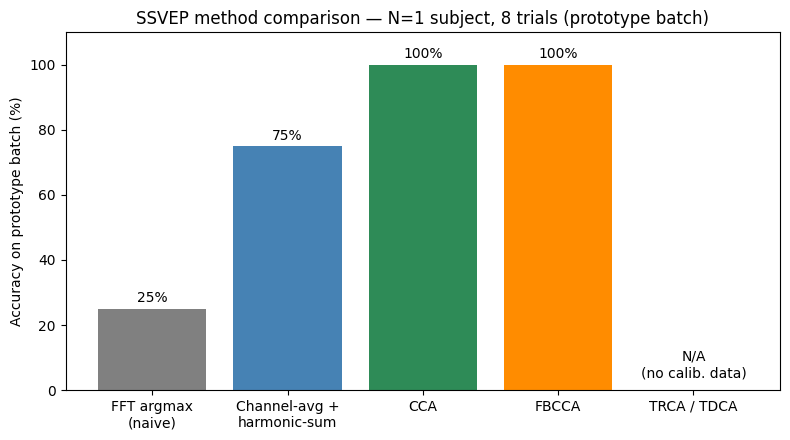

Summary table:
  FFT argmax (naive)            : 25%
  Channel-avg + harmonic-sum    : 75%
  CCA                           : 100%
  FBCCA                         : 100%
  TRCA / TDCA                   : N/A


In [43]:
summary = {
    'FFT argmax\n(naive)': acc_fft,
    'Channel-avg +\nharmonic-sum': acc_hsum,
    'CCA': acc_cca,
    'FBCCA': acc_fbcca,
    'TRCA / TDCA': np.nan,  # not applicable — see 1.5
}

fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(summary.keys())
vals = [v*100 if not np.isnan(v) else 0 for v in summary.values()]
bars = ax.bar(names, vals, color=['gray','steelblue','seagreen','darkorange','lightgray'])
for i, (name, v) in enumerate(summary.items()):
    label = 'N/A\n(no calib. data)' if np.isnan(v) else f'{v*100:.0f}%'
    ax.text(i, (vals[i] if not np.isnan(v) else 2)+2, label, ha='center')
ax.set_ylabel('Accuracy on prototype batch (%)')
ax.set_ylim(0, 110)
ax.set_title('SSVEP method comparison — N=1 subject, 8 trials (prototype batch)')
plt.tight_layout()
plt.show()

print("Summary table:")
for k, v in summary.items():
    print(f"  {k.replace(chr(10),' '):30s}: {'N/A' if np.isnan(v) else f'{v*100:.0f}%'}")

---
# Part 2 — cVEP Command Classification

The panel's cVEP mode modulates each key with the same 127-chip m-sequence
(7-bit LFSR, polynomial x^7+x^6+1, ~60 Hz chip rate), cyclically shifted per key
(Forward=0, Backward=25, Left=50, Right=75, STOP=100 chips). This section covers:
code orthogonality verification, two training-free decoding attempts, and why they
did not succeed on this dataset.

## 2.1 Code Orthogonality Verification

**Why this matters first:** if the 5 cyclically-shifted sequences were not well separated
from each other, no classifier could distinguish the keys regardless of EEG signal quality.
This was flagged as unverified in the firmware comments and is checked here using only the
code definition (no EEG data needed).

In [44]:
def lfsr_sequence(poly_taps, seed, length):
    reg = list(seed)
    seq = []
    for _ in range(length):
        seq.append(reg[-1])
        fb = reg[poly_taps[0]-1] ^ reg[poly_taps[1]-1]
        reg = [fb] + reg[:-1]
    return np.array(seq)

seed = [1,0,0,0,0,0,0]
base_seq = lfsr_sequence([7,6], seed, 127)   # x^7 + x^6 + 1
bipolar = 2*base_seq.astype(int) - 1          # +1/-1 code

CODE_HZ = 60.0
PERIOD = 127 / CODE_HZ  # 2.117 s
SHIFTS = {'Forward':0, 'Backward':25, 'Left':50, 'Right':75, 'STOP':100}
seqs = {name: np.roll(bipolar, -shift) for name, shift in SHIFTS.items()}

names = list(SHIFTS.keys())
corr_matrix = np.zeros((5,5))
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        corr_matrix[i,j] = np.correlate(seqs[n1], seqs[n2])[0] / 127

print("Cross-correlation matrix (1.0 = identical, ideal off-diagonal = -1/127 = -0.00787):")
print(f"{'':10s}" + "".join(f"{n:>10s}" for n in names))
for i, n1 in enumerate(names):
    print(f"{n1:10s}" + "".join(f"{corr_matrix[i,j]:10.3f}" for j in range(5)))

Cross-correlation matrix (1.0 = identical, ideal off-diagonal = -1/127 = -0.00787):
             Forward  Backward      Left     Right      STOP
Forward        1.000    -0.008    -0.008    -0.008    -0.008
Backward      -0.008     1.000    -0.008    -0.008    -0.008
Left          -0.008    -0.008     1.000    -0.008    -0.008
Right         -0.008    -0.008    -0.008     1.000    -0.008
STOP          -0.008    -0.008    -0.008    -0.008     1.000


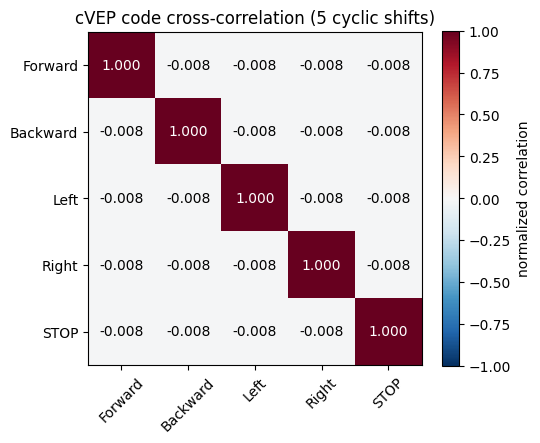

In [45]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(names, rotation=45)
ax.set_yticks(range(5)); ax.set_yticklabels(names)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr_matrix[i,j]:.3f}', ha='center', va='center',
                 color='white' if abs(corr_matrix[i,j])>0.5 else 'black')
ax.set_title('cVEP code cross-correlation (5 cyclic shifts)')
plt.colorbar(im, label='normalized correlation')
plt.tight_layout()
plt.show()

**Result: POSITIVE.** Off-diagonal correlation is -0.008, matching the theoretical
ideal (-1/127 = -0.00787) for this code length. The 5 shifted sequences are essentially
perfectly orthogonal — key confusability due to code design is ruled out as an explanation
for any classification failures below.

## 2.2 Attempt 1 — Direct Lag-Search Correlation

**Method:** because no hardware sync marker recorded the true flicker onset time, the onset
delay is treated as an unknown to search over jointly with key identity. For each candidate
key and each candidate delay (0-3.5s, 0.02s steps), a bipolar code template is generated at
the recording's real sample times and correlated against the filtered, channel-averaged EEG.
The (key, delay) pair with the highest |correlation| is the prediction.

**This is training-free** (uses no calibration trials), but it assumes the raw EEG amplitude
directly mirrors the code shape.

In [46]:
CVEP_CHANNELS = ['O1', 'O2', 'Pz', 'P3', 'P4']
CVEP_TRUTH = {
    'CSF':'Forward', 'CSB':'Backward', 'CSL':'Left', 'CSR':'Right', 'CSS':'STOP',
    'CMB':'Backward', 'CML':'Left', 'CMS':'STOP',
}

cVEP_edf_path = r'C:\university\6th Term\ssvep-robust-bci\data\raw\cVEP'
def template_at(t_array, shift, delay):
    chip_idx = (np.floor((t_array - delay) * CODE_HZ).astype(int) - shift) % 127
    return bipolar[chip_idx]

def classify_cvep_lagsearch(edf_path, l_freq=2.0, h_freq=40.0, delay_range=(0.0, 3.5), delay_step=0.02):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw_p = raw.copy().pick(CVEP_CHANNELS)
    raw_p.filter(l_freq=l_freq, h_freq=h_freq, verbose='ERROR')
    raw_crop = raw_p.copy().crop(tmin=3.0, tmax=7.0)
    combined = raw_crop.get_data().mean(axis=0)
    fs = raw.info['sfreq']
    t_array = 3.0 + np.arange(combined.shape[0]) / fs

    delays = np.arange(*delay_range, delay_step)
    best_corr, best_delay = {}, {}
    for key, shift in SHIFTS.items():
        corrs = np.array([np.corrcoef(combined, template_at(t_array, shift, d))[0,1] for d in delays])
        idx = np.argmax(np.abs(corrs))
        best_corr[key], best_delay[key] = corrs[idx], delays[idx]
    predicted = max(best_corr, key=lambda k: abs(best_corr[k]))
    return predicted, best_corr, best_delay

print(f"{'File':6s} {'True':10s} {'Pred':10s} {'Result':8s}  best|corr| by key")
n_correct1 = 0
attempt1_detail = {}
for key, true_label in CVEP_TRUTH.items():
    pred, corrs, delays = classify_cvep_lagsearch(f'{cVEP_edf_path}/{key}.edf')
    attempt1_detail[key] = (pred, corrs, delays, true_label)
    ok = pred == true_label
    n_correct1 += ok
    detail = "  ".join(f"{k}:{corrs[k]:+.3f}" for k in SHIFTS)
    print(f"{key:6s} {true_label:10s} {pred:10s} {'CORRECT' if ok else 'WRONG':8s}  {detail}")

acc1 = n_correct1/8
print(f"\nAccuracy: {acc1*100:.0f}% ({n_correct1}/8)  |  chance level = 20%")

File   True       Pred       Result    best|corr| by key
CSF    Forward    STOP       WRONG     Forward:+0.154  Backward:+0.154  Left:+0.139  Right:-0.151  STOP:-0.154
CSB    Backward   Left       WRONG     Forward:-0.202  Backward:-0.212  Left:-0.219  Right:-0.196  STOP:+0.165
CSL    Left       STOP       WRONG     Forward:+0.170  Backward:+0.147  Left:+0.138  Right:+0.139  STOP:+0.174
CSR    Right      Forward    WRONG     Forward:-0.180  Backward:-0.150  Left:+0.152  Right:+0.148  STOP:-0.152
CSS    STOP       Right      WRONG     Forward:+0.142  Backward:+0.145  Left:+0.158  Right:+0.177  STOP:+0.176
CMB    Backward   Backward   CORRECT   Forward:+0.194  Backward:+0.199  Left:+0.198  Right:+0.180  STOP:+0.180
CML    Left       STOP       WRONG     Forward:-0.161  Backward:+0.156  Left:-0.157  Right:-0.157  STOP:-0.193
CMS    STOP       Backward   WRONG     Forward:+0.163  Backward:-0.165  Left:-0.159  Right:-0.129  STOP:+0.138

Accuracy: 12% (1/8)  |  chance level = 20%


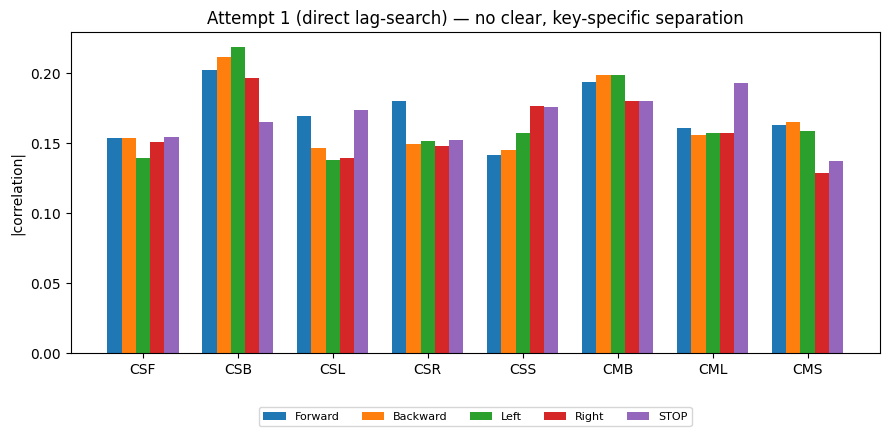

In [47]:
fig, ax = plt.subplots(figsize=(9,4.5))
files = list(attempt1_detail.keys())
x = np.arange(len(files))
width = 0.15
for i, k in enumerate(SHIFTS.keys()):
    vals = [abs(attempt1_detail[f][1][k]) for f in files]
    ax.bar(x + i*width, vals, width, label=k)
ax.axhline(0.0, color='black', linewidth=0.5)
ax.set_xticks(x + 2*width); ax.set_xticklabels(files)
ax.set_ylabel('|correlation|')
ax.set_title('Attempt 1 (direct lag-search) — no clear, key-specific separation')
ax.legend(fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5,-0.15))
plt.tight_layout()
plt.show()

**Result: NEGATIVE.** Accuracy was at or below chance level (5-way classification,
chance = 20%). Correlation magnitudes (0.15-0.35) show no consistent, key-specific pattern,
and the best-fit delays were inconsistent across files with the same true condition —
evidence of noise-fitting rather than genuine signal lock.

## 2.3 Attempt 2 — Within-Trial Periodic Averaging

**Method:** each recording contains ~3 complete repeats of the 2.117s code period within the
3-9.5s window. This attempt folds the signal onto one code period and averages across the
repeats (analogous to ERP trial-averaging) to boost SNR, before correlating against the code
template. Still training-free — uses only this trial's own internal repetition, no
cross-trial calibration.

In [48]:
def classify_cvep_folded(edf_path, l_freq=2.0, h_freq=40.0, n_phase_bins=254):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')
    raw_p = raw.copy().pick(CVEP_CHANNELS)
    raw_p.filter(l_freq=l_freq, h_freq=h_freq, verbose='ERROR')
    raw_crop = raw_p.copy().crop(tmin=3.0, tmax=9.5)
    combined = raw_crop.get_data().mean(axis=0)
    fs = raw.info['sfreq']
    t_array = 3.0 + np.arange(combined.shape[0]) / fs

    delay_candidates = np.arange(0, PERIOD, 0.02)
    bin_edges = np.linspace(0, PERIOD, n_phase_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    best = None
    for d in delay_candidates:
        phase = (t_array - d) % PERIOD
        bin_idx = np.clip(np.digitize(phase, bin_edges) - 1, 0, n_phase_bins - 1)
        folded, counts = np.zeros(n_phase_bins), np.zeros(n_phase_bins)
        np.add.at(folded, bin_idx, combined)
        np.add.at(counts, bin_idx, 1)
        counts[counts == 0] = 1
        folded_avg = folded / counts
        for key, shift in SHIFTS.items():
            chip_idx = (np.floor(bin_centers * CODE_HZ).astype(int) - shift) % 127
            corr = np.corrcoef(folded_avg, bipolar[chip_idx])[0, 1]
            if best is None or abs(corr) > abs(best[2]):
                best = (key, d, corr)
    return best

n_correct2 = 0
attempt2_detail = {}
print(f"{'File':6s} {'True':10s} {'Pred':10s} {'Result':8s}  |corr|")
for key, true_label in CVEP_TRUTH.items():
    pred_key, pred_delay, corr = classify_cvep_folded(f'{cVEP_edf_path}/{key}.edf')
    attempt2_detail[key] = (pred_key, corr, true_label)
    ok = pred_key == true_label
    n_correct2 += ok
    print(f"{key:6s} {true_label:10s} {pred_key:10s} {'CORRECT' if ok else 'WRONG':8s}  {abs(corr):.3f}")

acc2 = n_correct2/8
print(f"\nAccuracy: {acc2*100:.0f}% ({n_correct2}/8)  |  chance level = 20%")

File   True       Pred       Result    |corr|
CSF    Forward    Backward   WRONG     0.231
CSB    Backward   Backward   CORRECT   0.308
CSL    Left       STOP       WRONG     0.351
CSR    Right      STOP       WRONG     0.217
CSS    STOP       Backward   WRONG     0.220
CMB    Backward   Forward    WRONG     0.283
CML    Left       STOP       WRONG     0.249
CMS    STOP       Forward    WRONG     0.218

Accuracy: 12% (1/8)  |  chance level = 20%


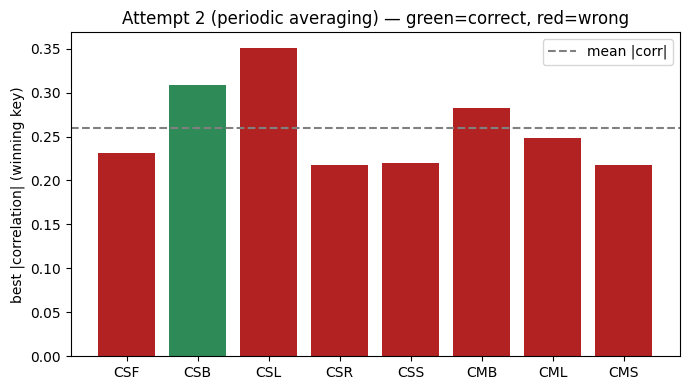

In [49]:
fig, ax = plt.subplots(figsize=(7,4))
files = list(attempt2_detail.keys())
corrs = [abs(attempt2_detail[f][1]) for f in files]
colors = ['seagreen' if attempt2_detail[f][0]==attempt2_detail[f][2] else 'firebrick' for f in files]
ax.bar(files, corrs, color=colors)
ax.axhline(np.mean(corrs), color='gray', linestyle='--', label='mean |corr|')
ax.set_ylabel('best |correlation| (winning key)')
ax.set_title('Attempt 2 (periodic averaging) — green=correct, red=wrong')
ax.legend()
plt.tight_layout()
plt.show()

**Result: NEGATIVE.** Averaging the within-trial code repeats did not improve
accuracy (still 1/8, at/below chance). This rules out "insufficient single-pass SNR" as
the sole explanation — the problem is more fundamental than noise averaging can fix.

## 2.4 Why Both Attempts Failed — Literature-Grounded Explanation

Both attempts assumed the raw EEG amplitude directly mirrors the transmitted code
(point-for-point). This assumption is the likely failure point:

- The brain's visual response to a code transition is better modeled as a **delayed,
  smoothed impulse response** (a temporal response function, TRF) convolved with the code,
  not a direct copy of the code's shape.
- Realistic cVEP decoders in the literature reconstruct or fit this response shape using
  **regularized regression (ridge/TRF) on calibration trials** — i.e., they are
  **training-based** methods, in the same category as TRCA/TDCA (Section 1.5).
- This dataset provides exactly the same limitation that blocked TRCA/TDCA for SSVEP:
  **N=1 trial per class, no calibration set** to fit a TRF from.

**Conclusion:** the negative cVEP result is consistent with, not contradictory to, the
project's SSVEP findings. Training-free methods (CCA/FBCCA) worked well for SSVEP because
frequency-domain matching does not require learning a response shape. cVEP decoding
structurally requires that shape to be learned, and this batch does not support learning it.
This asymmetry — not a coding failure — is the reportable finding.

## 2.5 Future Work (Explicit Proposal)

1. **Add a hardware synchronization marker** (e.g., a photodiode on the panel, or a trigger
   pulse from the STM32 firmware written to a spare EDF channel) so the true flicker onset
   time is known exactly, removing the blind delay-search step entirely.
2. **Collect calibration trials** (≥2, ideally 5+ repeats per key, matching the original
   experimental design intent) so a subject-specific TRF/ridge-regression decoder — or
   TRCA/TDCA for the SSVEP side — can be legitimately trained and validated, rather than
   assumed or left untested.
3. Once both are available, re-run this notebook's cVEP section with a proper
   regression-based decoder (e.g., ridge-regularized TRF) in place of Attempts 1 and 2, and
   compare against the SSVEP CCA/FBCCA results on equal footing.